# What Remains of Cross-Country Convergence?

**Paul Johnson**  
**Chris Papageorgiou**

*2018*

### Bibliotecas

In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas padrão
import warnings
import os

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
import matplotlib.lines as mlines

# Utilidades / Jupyter
from IPython.display import display

# Estatística
from scipy import stats

### Configurações

In [ ]:
# Definindo diretório dos dados
os.chdir('G:/Meu Drive/MeuDrive2/GitHub/estag_doc_macro_iii/dados')

# Evitar avisos desnecessários
warnings.filterwarnings('ignore')

# Exibir todas as linhas e colunas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### I. Introdução 

- A hipótese de convergência afirma que, no longo prazo, países mais pobres tendem a alcançar os mais ricos, reduzindo as diferenças de renda per capita.

- Avalia criticamente a convergência à luz das mudanças globais e da diversidade de trajetórias de crescimento.

- Foco na convergência internacional da renda, mais especificamente na convergência da renda per capita.

### II. Padrões e fatos sobre o crescimento ao longo do último meio século

##### Contexto

- Análise baseada no conjunto de dados Penn World Table version 7.1 (PWT 7.1)
- 182 Países
- 1950 - 2010

##### Crescimento global

In [4]:
# Importar os dados
df = pd.read_stata("Main_Data.dta")

# Exibir as primeiras observações
df.head()

,ifscode,wbcode,country,year,region,incomegroup,POP,XRAT,Currency_Unit,ppp,tcgdp,cgdp,cgdp2,cda2,cc,cg,ci,p,p2,pc,pg,pi,openc,cgnp,y,y2,rgdpl,rgdpl2,rgdpch,kc,kg,ki,openk,rgdpeqa,rgdpwok,rgdpl2wok,rgdpl2pe,rgdpl2te,rgdpl2th,rgdptt,lidc,lidc_small,lidc_fragile,lidc_comexp
0,111.0,USA,United States,1950,North America,High income,151868.0,1.0,US Dollar,1.0,294002.2176,1935.906297,1935.906297,1927.108757,69.446244,10.224296,19.875020,100.0,100.0,100.905826,77.579520,108.368666,8.206487,NaN,100.0,100.0,13046.22922,13375.87673,13069.19679,70.290773,10.190655,20.007391,6.070080,15125.07681,31177.61093,31909.22040,NaN,33427.18915,17.512768,13171.35580,NaN,NaN,NaN,NaN
1,111.0,USA,United States,1951,North America,High income,153982.0,1.0,US Dollar,1.0,339442.4140,2204.429180,2204.429180,2182.702429,67.158528,13.199826,18.656050,100.0,100.0,100.244202,83.182468,111.019923,9.436355,NaN,100.0,100.0,14141.45547,14769.80465,14173.04146,67.801625,13.772595,18.431066,6.192986,16450.10796,33989.78289,35420.94017,NaN,35982.38670,18.755013,14289.23007,NaN,NaN,NaN,NaN
2,111.0,USA,United States,1952,North America,High income,156393.0,1.0,US Dollar,1.0,358848.9344,2294.533223,2294.533223,2282.509939,68.459062,14.990329,16.026612,100.0,100.0,99.964831,86.832853,112.465984,8.901002,NaN,100.0,100.0,14633.55115,15502.03761,14648.23869,68.568581,15.920538,15.955508,5.968079,17051.07465,35325.88435,37384.91701,NaN,37879.63812,19.798347,14780.61662,NaN,NaN,NaN,NaN
3,111.0,USA,United States,1953,North America,High income,158956.0,1.0,US Dollar,1.0,377837.4326,2376.993838,2376.993838,2376.834148,68.770535,15.498529,15.724218,100.0,100.0,100.024850,84.268638,115.396889,8.378731,NaN,100.0,100.0,15014.69833,15917.47538,15028.81544,68.729576,16.092900,15.988921,5.915875,17545.08276,36441.98121,38596.81032,NaN,39015.53367,20.425126,15137.60471,NaN,NaN,NaN,NaN
4,111.0,USA,United States,1954,North America,High income,161884.0,1.0,US Dollar,1.0,376943.5919,2328.479602,2328.479602,2324.107332,69.339732,14.492632,15.979863,100.0,100.0,100.958780,83.724706,110.600236,8.475392,NaN,100.0,100.0,14417.93208,15197.35455,14438.89437,69.957276,14.708846,15.926716,6.071197,16905.67919,35201.49045,37050.58831,NaN,38696.68945,20.433082,14532.15821,NaN,NaN,NaN,NaN


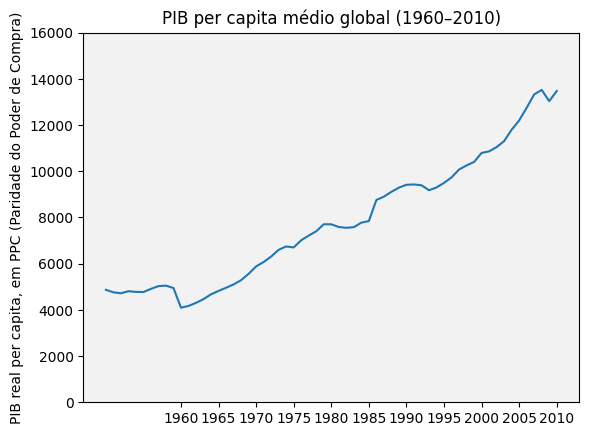

In [5]:
# Média agrupada de rgdpch por ano
df = df.groupby("year", as_index=False)["rgdpch"].mean()

# Plote 1
plt.figure()

plt.plot(df["year"], df["rgdpch"])

plt.title("PIB per capita médio global (1960–2010)")
plt.ylabel("PIB real per capita, em PPC (Paridade do Poder de Compra)")
plt.xlabel("")

plt.yticks(range(0, 16001, 2000))
plt.xticks(range(1960, 2011, 5))

plt.gca().set_facecolor("#f2f2f2")

##### Heterogeneidade entre regiões geográficas

In [6]:
all_sheets = pd.read_excel('Tables.xlsx', sheet_name=None, header=None)

Crescimento da renda per capita por região

In [7]:
df = all_sheets['Original Tables 1-2-4']

table1 = df.iloc[1:10, 1:8].copy()
table1.columns = ['Region', "1960's", "1970's", "1980's", "1990's", "2000's", "2010's"]

# Remover linha duplicada de cabeçalho
table1 = table1[table1['Region'] != 'Geographical Region']

# Remover última coluna
table1 = table1.drop(columns=["2010's"])

# Resetar índice
table1 = table1.reset_index(drop=True)

# Converter para porcentagem
cols = table1.columns[1:]
table1[cols] = table1[cols].astype(float) * 100

# Substituir NaN por "-"
table1 = table1.fillna("-")

print(table1)

                       Region 1960's 1970's 1980's 1990's 2000's
0         East Asia & Pacific    3.9    3.3    3.2    3.0    3.6
1       Europe & Central Asia    4.7    3.5    1.8    0.5    3.6
2   Latin America & Caribbean    2.2    2.7   -0.6    1.5    2.2
3  Middle East & North Africa    3.7    2.7   -0.9    2.0    2.0
4                  South Asia    1.6    1.4    2.1    0.5    4.5
5          Sub-Saharan Africa    1.8    1.3   -0.2   -0.4    1.8
6                           -      -      -      -      -      -
7                       World    2.8    2.4    0.6    0.9    2.7


Logaritmo da renda per capita por região (1960–2010)

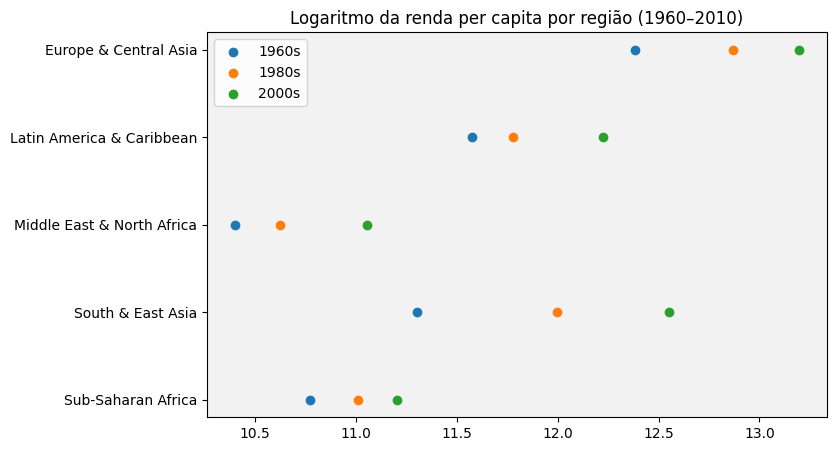

In [8]:
# Importando os dados
df = pd.read_excel("geographic-level-lnrgdp_pc.xlsx")

# Remover regiões
df = df[~df["region"].isin(["World", "North America"])]

# Ordenar (equivalente ao region_num invertido)
df = df.sort_values("region", ascending=False)

y = np.arange(len(df))

plt.figure(figsize=(8, 5))

plt.scatter(df["decade60"], y, label="1960s")
plt.scatter(df["decade80"], y, label="1980s")
plt.scatter(df["decade00"], y, label="2000s")

plt.yticks(y, df["region"])
plt.title("Logaritmo da renda per capita por região (1960–2010)")
plt.ylabel("")
plt.xlabel("")

plt.legend()

plt.gca().set_facecolor("#f2f2f2")

PIB per capita em relação aos Estados Unidos

In [9]:
# Importar os dados
df = pd.read_stata("Main_Data.dta")
df = df.sort_values(["country", "year"]).reset_index(drop=True)

In [10]:
# Remover pequenos LIDCs (POP ≤ 1000 em 2010)
small_mask  = (df["POP"] <= 1000) & (df["year"] == 2010)
small_codes = df.loc[small_mask, "ifscode"].unique()
df = df[~(df["lidc_small"] == 1)]
df = df[~df["ifscode"].isin(small_codes)]
 
# Nível de PIB per capita
df["region"] = df["region"].replace(
    {"East Asia & Pacific": "South & East Asia",
     "South Asia":          "South & East Asia"}
)
 
# Nível de PIB per capita
df["rgdpna_pc"] = df["rgdpch"] * df["POP"] * 1000
 
# Preencher indicadores (flags) ausentes
df["lidc_fragile"] = df["lidc_fragile"].fillna(0)
df["lidc_comexp"]  = df["lidc_comexp"].fillna(0)
 
# Cópia de incomegroup2
df["incomegroup2"] = df["incomegroup"]

In [11]:
# Remover países com observações faltantes por década
DECADES = {"60": 1969, "70": 1979, "80": 1989, "90": 1999, "00": 2000}
 
for tag, yr in DECADES.items():
    decade_vals = (
        df[df["year"] == yr]
        .set_index("ifscode")["rgdpna_pc"]
        .rename(f"aux_level{tag}")
    )
    df = df.merge(decade_vals, on="ifscode", how="left")
 
decade_cols = [f"aux_level{t}" for t in DECADES]
df = df.dropna(subset=decade_cols)
df = df.drop(columns=decade_cols)

Abaixo, correção da figura 3-B, o código acima será útil para os demais plotes

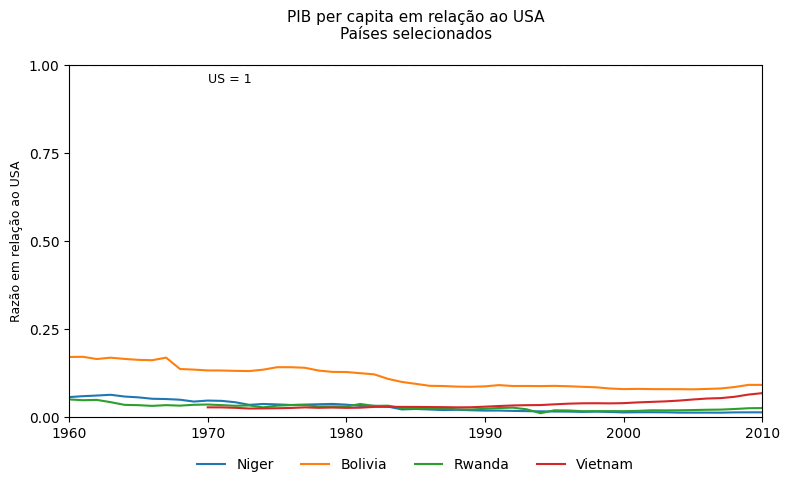

In [33]:
# importando os dados
df = pd.read_stata("Main_Data.dta")
df = df.sort_values(["country", "year"]).reset_index(drop=True)
 
# Remover alguns LICs
df["aux2"] = np.where((df["POP"] <= 1000) & (df["year"] == 2010), 1, np.nan)
df["aux3"] = df.groupby("ifscode")["aux2"].transform("mean")
df = df[~(df["lidc_small"] == 1)]
df = df[~(df["aux3"] == 1)]
df = df.drop(columns=["aux2", "aux3"])
df = df[df["year"] >= 1960].reset_index(drop=True)
 
# Filtrar
countries_b = ["Niger", "Bolivia", "Rwanda", "Vietnam"]
sub = df[df["country"].isin(countries_b) | (df["ifscode"] == 111)].copy()
 
# USA como referência
usa = sub[sub["ifscode"] == 111][["year", "rgdpch"]].rename(columns={"rgdpch": "rgdpch_USA"})
sub = sub.merge(usa, on="year")
sub["ratio"] = sub["rgdpch"] / sub["rgdpch_USA"]
 
# Plotar
colors = {"Niger": "tab:blue", "Bolivia": "tab:orange",
          "Rwanda": "tab:green", "Vietnam": "tab:red"}
 
fig, ax = plt.subplots(figsize=(8, 5))
for country, color in colors.items():
    s = sub[sub["country"] == country].sort_values("year")
    ax.plot(s["year"], s["ratio"], label=country, color=color)
 
ax.axhline(1, linestyle="--", color="gray")
ax.text(1970, 0.95, "US = 1", color="black", fontsize=9)
ax.set_title("PIB per capita em relação ao USA\nPaíses selecionados\n", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Razão em relação ao USA", fontsize=9)
ax.set_xlim(1960, 2010)
ax.set_xticks(range(1960, 2011, 10))
ax.set_ylim(0, 1)
ax.set_yticks([i * 0.25 for i in range(5)])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
plt.tight_layout()

##### Heterogeneidade entre grupos de renda e tipo de exportador

Crescimento médio por região

In [13]:
df = all_sheets['Original Tables 1-2-4']
table2 = df.iloc[14:27, 1:7].copy()
table2.columns = ['Group', "1960's", "1970's", "1980's", "1990's", "2000's"]

# Remover linhas indesejadas
table2 = table2[table2['Group'] != 'Income Group']

# Resetar índice
table2 = table2.reset_index(drop=True)

# Converter com segurança
cols = table2.columns[1:]
for col in cols:
    table2[col] = pd.to_numeric(table2[col], errors='coerce')

# Converter para porcentagem
table2[cols] = table2[cols] * 100

# Substituir NaN por "-"
table2 = table2.fillna("-")

print(table2)

                     Group 1960's 1970's 1980's 1990's 2000's
0                        -      -      -      -      -      -
1                      HIC    4.7    3.3    2.4    2.1    1.7
2                      MIC    2.8    3.4    0.4    1.4    3.4
3               LIC  (all)    1.4    0.7   -0.2   -0.5    2.4
4            LIC (fragile)    1.7    0.7   -0.5   -1.5    1.3
5        LIC (non-fragile)    1.1    0.7    0.2    0.6    3.6
6                        -      -      -      -      -      -
7           Exporter Group      -      -      -      -      -
8      Commodity Exporters    2.1    2.0   -0.8   -0.4    3.0
9                   Others    3.0    2.5    1.1    1.3    2.7
10                       -      -      -      -      -      -
11                   World    2.8    2.4    0.6    0.9    2.7


Logaritmo da renda per capita por grupo de renda (1960–2010)

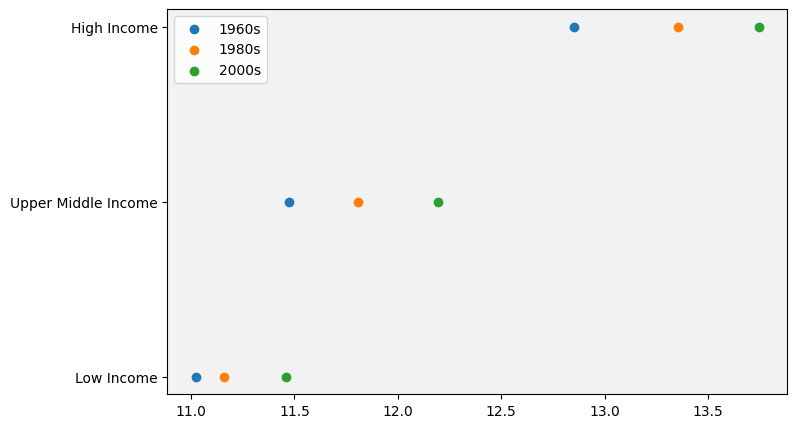

In [14]:
# Importar dados
df = pd.read_excel("incomegroup-level-lnrgdp_pc.xlsx")

# Criar variável de ordenação
df["aux2"] = df["decade00"] - df["decade60"]

# Ordenar
df = df.sort_values("aux2")# Criar variável de ordenação
df["aux2"] = df["decade00"] - df["decade60"]

# Ordenar
df = df.sort_values("aux2")

y = np.arange(len(df))

plt.figure(figsize=(8, 5))

plt.scatter(df["decade60"], y, label="1960s")
plt.scatter(df["decade80"], y, label="1980s")
plt.scatter(df["decade00"], y, label="2000s")

plt.yticks(y, df["incomegroup"])
plt.ylabel("")
plt.xlabel("")

plt.legend()

plt.gca().set_facecolor("#f2f2f2")

PIB em alguns grupos de renda selecionados em relação ao dos Estados Unidos

In [15]:
## Importar os dados
df = pd.read_stata("Main_Data.dta")
df = df.sort_values(["country", "year"]).reset_index(drop=True)

In [16]:
# remover pequenos LIDCs (POP ≤ 1000 em 2010)
small_mask  = (df["POP"] <= 1000) & (df["year"] == 2010)
small_codes = df.loc[small_mask, "ifscode"].unique()
df = df[~(df["lidc_small"] == 1)]
df = df[~df["ifscode"].isin(small_codes)]
 
# reclassificar regiões
df["region"] = df["region"].replace(
    {"East Asia & Pacific": "South & East Asia",
     "South Asia":          "South & East Asia"}
)
 
# nível de PIB per capita
df["rgdpna_pc"] = df["rgdpch"] * df["POP"] * 1000
 
# preencher indicadores (flags) ausentes
df["lidc_fragile"] = df["lidc_fragile"].fillna(0)
df["lidc_comexp"]  = df["lidc_comexp"].fillna(0)
 
# cópia de incomegroup2
df["incomegroup2"] = df["incomegroup"]

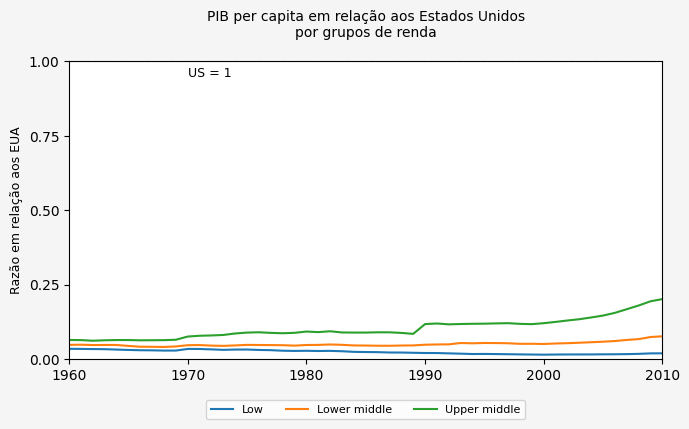

In [17]:
df3a = df.copy()
df3a["incomegroup_g"] = np.where(df3a["ifscode"] == 111, "USA", df3a["incomegroup2"])
 
# agregar: somar PIB e população por grupo-ano
agg = (
    df3a.groupby(["incomegroup_g", "year"])
    .agg(rgdpna_pc_sum=("rgdpna_pc", "sum"), POP_sum=("POP", "sum"))
    .reset_index()
)
agg["rgdpch"] = agg["rgdpna_pc_sum"] / (agg["POP_sum"] * 1000)
 
# remover "não classificado"
agg = agg[agg["incomegroup_g"] != "Not classified"]
 
# referência dos EUA
usa_ref = agg[agg["incomegroup_g"] == "USA"][["year", "rgdpch"]].rename(
    columns={"rgdpch": "rgdpch_usa"}
)
agg = agg.merge(usa_ref, on="year")
agg["ratio"] = agg["rgdpch"] / agg["rgdpch_usa"]
 
# manter pós-1959
agg = agg[agg["year"] >= 1960]
 
GROUPS = {
    "Low income":         ("Low",          "tab:blue"),
    "Lower middle income":("Lower middle", "tab:orange"),
    "Upper middle income":("Upper middle", "tab:green"),
}
 
fig, ax = plt.subplots(figsize=(7, 4.5))
for grp, (lbl, col) in GROUPS.items():
    sub = agg[agg["incomegroup_g"] == grp].sort_values("year")
    ax.plot(sub["year"], sub["ratio"], label=lbl, color=col)
 
ax.axhline(1, linestyle="--", color="gray", linewidth=0.8)
ax.text(1970, 0.95, "US = 1", fontsize=9)
ax.set_xlim(1960, 2010)
ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
ax.set_xlabel("")
ax.set_ylabel("Razão em relação aos EUA", fontsize=9)
ax.set_title("PIB per capita em relação aos Estados Unidos\npor grupos de renda\n", fontsize=10)
ax.legend(ncol=3, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.22))
ax.set_facecolor("white")
fig.patch.set_facecolor("#f5f5f5")
fig.tight_layout()

Taxa de crescimento ao longo de 1960–2010 em relação ao nível de 1960 do PIB real per capita
para todos os países para os quais há dados no PWT 7.1

In [18]:
# Importar dados
df = pd.read_stata("Main_Data.dta")
df = df.sort_values(["country", "year"]).reset_index(drop=True)
df["rgdpna_pc"] = df["rgdpch"]

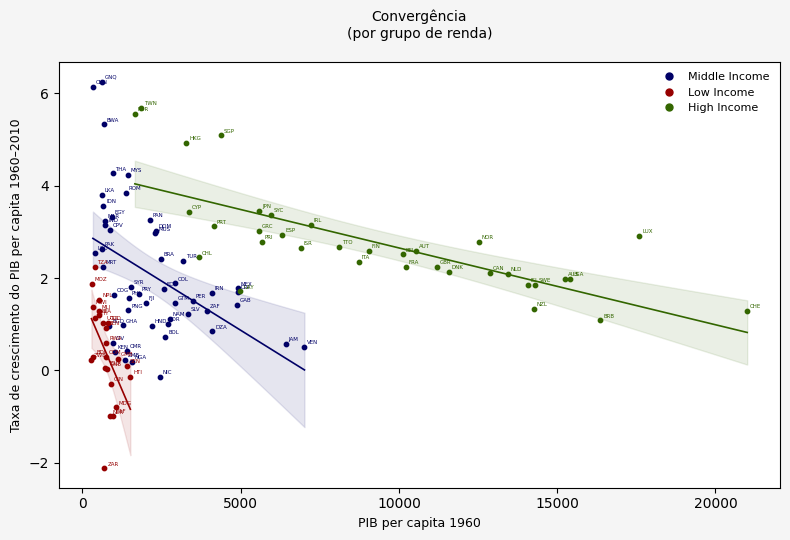

In [19]:
# Gráfico de dispersão de convergência (crescimento de 1960–2010 vs nível de 1960)
fig4_df = df[df["year"].isin([1960, 2010])].copy()
fig4_df = fig4_df.sort_values(["country", "year"])
 
# taxa de crescimento 1960–2010 (anualizada ×100, ao longo de 50 anos)
fig4_df["log_rgdp"] = np.log(fig4_df["rgdpna_pc"])
fig4_wide = fig4_df.pivot(index=["country", "wbcode", "incomegroup"], columns="year", values=["rgdpna_pc", "log_rgdp"])
fig4_wide.columns = ["_".join(map(str, c)) for c in fig4_wide.columns]
fig4_wide = fig4_wide.reset_index()
fig4_wide["gr"] = (fig4_wide["log_rgdp_2010"] - fig4_wide["log_rgdp_1960"]) * 100 / 50
fig4_wide = fig4_wide.dropna(subset=["gr", "rgdpna_pc_1960"])
 
# Grupos de renda
fig4_wide["ig3"] = fig4_wide["incomegroup"].replace(
    {"Lower middle income": "Middle Income",
     "Upper middle income": "Middle Income"}
)
 
GROUPS_4 = {
    "Middle Income": {"color": (0/255,   0/255, 102/255), "label": "Middle Income"},
    "Low income":    {"color": (150/255, 0/255,   0/255), "label": "Low Income"},
    "High income":   {"color": (51/255, 102/255,  0/255), "label": "High Income"},
}
 
fig, ax = plt.subplots(figsize=(8, 5.5))
 
for grp, cfg in GROUPS_4.items():
    sub = fig4_wide[fig4_wide["ig3"] == grp]
    c   = cfg["color"]
 
    # pontos de dispersão
    ax.scatter(sub["rgdpna_pc_1960"], sub["gr"],
               color=c, s=10, zorder=3)
 
    # rótulos dos países
    for _, row in sub.iterrows():
        ax.annotate(row["wbcode"],
                    (row["rgdpna_pc_1960"], row["gr"]),
                    fontsize=4, color=c,
                    xytext=(2, 2), textcoords="offset points")
 
    # ajuste linear + intervalo de confiança
    x = sub["rgdpna_pc_1960"].values
    y = sub["gr"].values
    if len(x) > 2:
        slope, intercept, *_ = stats.linregress(x, y)
        x_sorted = np.linspace(x.min(), x.max(), 200)
        y_fit    = intercept + slope * x_sorted
 
        # intervalo de confiança de 95% via erro padrão dos resíduos
        n    = len(x)
        y_hat = intercept + slope * x
        se   = np.sqrt(np.sum((y - y_hat)**2) / (n - 2))
        x_m  = x.mean()
        se_fit = se * np.sqrt(1/n + (x_sorted - x_m)**2 / np.sum((x - x_m)**2))
        t_val  = stats.t.ppf(0.975, df=n - 2)
 
        ax.plot(x_sorted, y_fit, color=c, linewidth=1.2)
        ax.fill_between(x_sorted,
                        y_fit - t_val * se_fit,
                        y_fit + t_val * se_fit,
                        color=c, alpha=0.10)
 
handles = [
    mlines.Line2D([], [], color=cfg["color"], marker="o",
                  markersize=5, linestyle="None", label=cfg["label"])
    for cfg in GROUPS_4.values()
]
ax.legend(handles=handles, loc="upper right", fontsize=8,
          frameon=False)
 
ax.set_title("Convergência\n(por grupo de renda)\n", fontsize=10)
ax.set_xlabel("PIB per capita 1960", fontsize=9)
ax.set_ylabel("Taxa de crescimento do PIB per capita 1960–2010", fontsize=9)
ax.set_facecolor("white")
fig.patch.set_facecolor("#f5f5f5")
fig.tight_layout()

Distribuição de renda entre países em relação ao log do PIB per capita (1960, 2010)

In [20]:
# Importar
df = pd.read_stata("Main_Data.dta")
 
df["Yp"] = np.log(df["rgdpch"])
df = df[["wbcode", "ifscode", "year", "Yp"]].copy()
 
# contar observações não ausentes de Yp por país a partir de 1960
df_from1960 = df[(df["year"] >= 1960) & (df["Yp"].notna())]
sy = df_from1960.groupby("ifscode")["Yp"].count().rename("sy")
df = df.merge(sy, on="ifscode", how="left")
 
# Filtrar os anos desejados
df = df[(df["year"] >= 1960) & (df["year"] != 2015)]
df = df[(df["sy"] >= 51) & (df["sy"].notna())]

In [21]:
# testes de razão de variância (equivalente ao sdtest)
def levene_ftest(df, year1, year2):
    """Replicates Stata sdtest: F-test for equality of variances."""
    g1 = df.loc[df["year"] == year1, "Yp"].dropna()
    g2 = df.loc[df["year"] == year2, "Yp"].dropna()
    var1, var2 = g1.var(ddof=1), g2.var(ddof=1)
    F = var1 / var2
    df1, df2 = len(g1) - 1, len(g2) - 1
    p_upper = 1 - stats.f.cdf(F, df1, df2)
    p_two   = 2 * min(p_upper, 1 - p_upper)
    print(f"\n  sdtest Yp: {year1} vs {year2}")
    print(f"    SD {year1} = {g1.std(ddof=1):.4f}  |  SD {year2} = {g2.std(ddof=1):.4f}")
    print(f"    F({df1},{df2}) = {F:.4f}  |  p-value (two-sided) = {p_two:.4f}")
 
levene_ftest(df, 1960, 1990)
levene_ftest(df, 1990, 2010)
levene_ftest(df, 1960, 2010)


  sdtest Yp: 1960 vs 1990
    SD 1960 = 1.1419  |  SD 1990 = 1.3683
    F(109,109) = 0.6965  |  p-value (two-sided) = 0.0603

  sdtest Yp: 1990 vs 2010
    SD 1990 = 1.3683  |  SD 2010 = 1.4438
    F(109,109) = 0.8981  |  p-value (two-sided) = 0.5756

  sdtest Yp: 1960 vs 2010
    SD 1960 = 1.1419  |  SD 2010 = 1.4438
    F(109,109) = 0.6255  |  p-value (two-sided) = 0.0150


In [22]:
# estatísticas descritivas
def summarise(df, year):
    sub = df.loc[df["year"] == year, "Yp"].dropna()
    return sub.mean(), sub.median(), len(sub)
 
mean60, med60, n60 = summarise(df, 1960)
mean90, med90, n90 = summarise(df, 1990)
mean10, med10, n10 = summarise(df, 2010)
 
print(f"\n--- Summary ---")
print(f"  1960 mean={mean60:.4f}, median={med60:.4f}  => exp(median)={np.exp(med60):.0f}")
print(f"  1990 mean={mean90:.4f}")
print(f"  2010 mean={mean10:.4f}, median={med10:.4f}  => exp(median)={np.exp(med10):.0f}")
 
# países em 2010 com Yp ≤ mediana de 1960
below_med = df[(df["year"] == 2010) & (df["Yp"] <= med60)].shape[0]
total_2010 = df[(df["year"] == 2010) & (df["Yp"].notna())].shape[0]
print(f"\n Países em 2010 com Yp ≤ mediana de 1960: {below_med} / {total_2010}")
print(f"  Ratio: {below_med / total_2010:.4f}")


--- Summary ---
  1960 mean=7.7052, median=7.6784  => exp(median)=2161
  1990 mean=8.2996
  2010 mean=8.6671, median=8.8072  => exp(median)=6682

 Países em 2010 com Yp ≤ mediana de 1960: 33 / 110
  Ratio: 0.3000


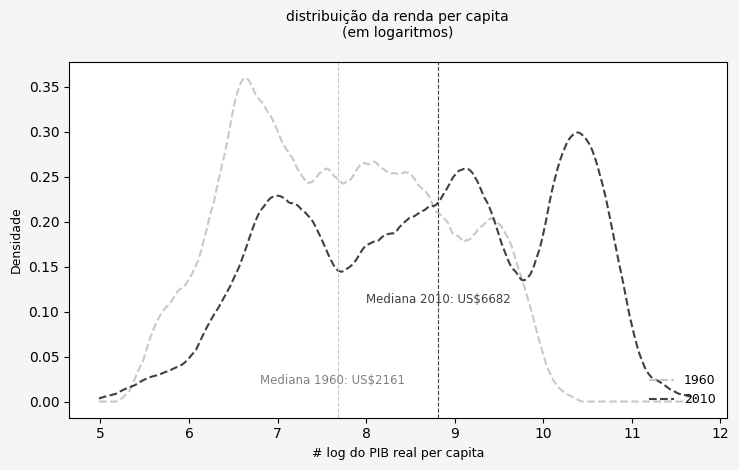

In [ ]:
# gráfico de densidade KDE
y1960 = df.loc[df["year"] == 1960, "Yp"].dropna().values
y2010 = df.loc[df["year"] == 2010, "Yp"].dropna().values
 
def epanechnikov_kde(data, x_grid, bw=None):
    """KDE com kernel Epanechnikov."""
    n = len(data)
    if bw is None:
        # regra de Silverman 
        bw = 1.06 * np.std(data, ddof=1) * n**(-0.2)
    density = np.zeros_like(x_grid, dtype=float)
    for xi in data:
        u = (x_grid - xi) / bw
        mask = np.abs(u) <= 1
        density[mask] += 0.75 * (1 - u[mask]**2)
    density /= (n * bw)
    return density
 
x_grid = np.linspace(
    min(y1960.min(), y2010.min()) - 0.5,
    max(y1960.max(), y2010.max()) + 0.5,
    500
)
 
kde_1960 = epanechnikov_kde(y1960, x_grid)
kde_2010 = epanechnikov_kde(y2010, x_grid)
 
fig, ax = plt.subplots(figsize=(7.5, 4.8))
 
ax.plot(x_grid, kde_1960, color="#c8c8c8", linestyle="--", linewidth=1.5, label="1960")
ax.plot(x_grid, kde_2010, color="#404040", linestyle="--", linewidth=1.5, label="2010")
 
# Linhas verticais na mediana
ax.axvline(med60, color="#c8c8c8", linestyle="--", linewidth=0.8)
ax.axvline(med10, color="#404040", linestyle="--", linewidth=0.8)
 
# rótulos da mediana
ax.text(6.8,  0.020, "Mediana 1960: US$2161", color="#808080", fontsize=8.5)
ax.text(8.0,  0.110, "Mediana 2010: US$6682", color="#404040", fontsize=8.5)
 
ax.set_title("distribuição da renda per capita\n(em logaritmos)\n", fontsize=10)
ax.set_xlabel("log do PIB real per capita", fontsize=9)
ax.set_ylabel("Densidade", fontsize=9)
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.set_facecolor("white")
fig.patch.set_facecolor("#f5f5f5")
fig.tight_layout()

Dispersão de renda entre países (1960–2010)

In [24]:
# Importar
df = pd.read_stata("Main_Data.dta")
 
df["Yp"] = np.log(df["rgdpch"])
df = df[["wbcode", "ifscode", "year", "Yp"]].copy()
 
# contar observações não ausentes de Yp por país a partir de 1960
sy = (
    df[(df["year"] >= 1960) & (df["Yp"].notna())]
    .groupby("ifscode")["Yp"]
    .count()
    .rename("sy")
)
df = df.merge(sy, on="ifscode", how="left")
 
# Filtrar anos
df = df[(df["year"] >= 1960) & (df["year"] != 2015)]
df = df[(df["sy"] >= 51) & (df["sy"].notna())]
 
# agregar: desvio padrão de Yp por ano
collapsed = df.groupby("year")["Yp"].std(ddof=1).reset_index()
collapsed.columns = ["year", "Yp"]
collapsed = collapsed.sort_values("year")

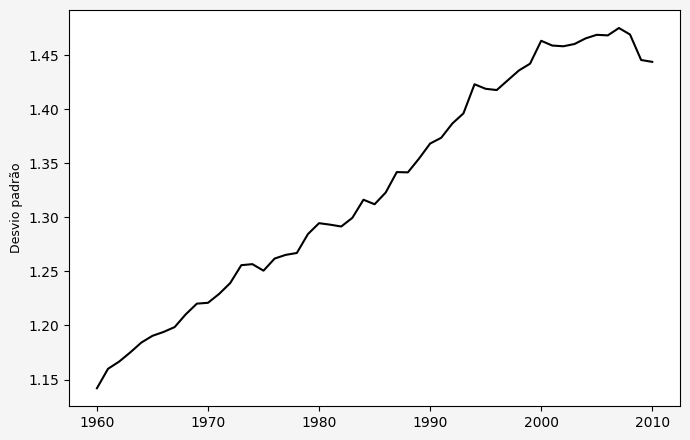

In [25]:
# desvio padrão do log do PIB per capita ao longo do tempo
fig, ax = plt.subplots(figsize=(7, 4.5))
 
ax.plot(collapsed["year"], collapsed["Yp"], color="black", linewidth=1.5)
 
ax.set_xlabel("", fontsize=9)
ax.set_ylabel("Desvio padrão", fontsize=9)
ax.set_facecolor("white")
fig.patch.set_facecolor("#f5f5f5")
fig.tight_layout()

##### Heterogeneidade dentro dos LICs

In [26]:
df = all_sheets['Original Tables 1-2-4']
table2 = df.iloc[14:27, 1:7].copy()
table2.columns = ['Group', "1960's", "1970's", "1980's", "1990's", "2000's"]

# Remover linhas indesejadas
table2 = table2[table2['Group'] != 'Income Group']

# Resetar índice
table2 = table2.reset_index(drop=True)

# Converter com segurança
cols = table2.columns[1:]
for col in cols:
    table2[col] = pd.to_numeric(table2[col], errors='coerce')

# Converter para porcentagem
table2[cols] = table2[cols] * 100

# Substituir NaN por "-"
table2 = table2.fillna("-")

print(table2)

                     Group 1960's 1970's 1980's 1990's 2000's
0                        -      -      -      -      -      -
1                      HIC    4.7    3.3    2.4    2.1    1.7
2                      MIC    2.8    3.4    0.4    1.4    3.4
3               LIC  (all)    1.4    0.7   -0.2   -0.5    2.4
4            LIC (fragile)    1.7    0.7   -0.5   -1.5    1.3
5        LIC (non-fragile)    1.1    0.7    0.2    0.6    3.6
6                        -      -      -      -      -      -
7           Exporter Group      -      -      -      -      -
8      Commodity Exporters    2.1    2.0   -0.8   -0.4    3.0
9                   Others    3.0    2.5    1.1    1.3    2.7
10                       -      -      -      -      -      -
11                   World    2.8    2.4    0.6    0.9    2.7


##### Melhores e piores desempenhos de crescimento ao longo do tempo

In [27]:
# Configuração para exibir tabela completa (sem quebra)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Carregar dados
df3 = all_sheets['Original Table 3']

# Selecionar e renomear colunas
table3 = df3.iloc[1:, 1:8].copy()
table3.columns = ['Decade', 'Top Rank', 'Top Country', 'Top Growth',
                  'Bot Rank', 'Bot Country', 'Bot Growth']

# Remover linhas inválidas
table3 = table3.dropna(subset=['Top Rank'])

# Resetar índice
table3 = table3.reset_index(drop=True)

# Converter colunas numéricas com segurança
num_cols = ['Top Rank', 'Top Growth', 'Bot Rank', 'Bot Growth']
for col in num_cols:
    table3[col] = pd.to_numeric(table3[col], errors='coerce')

# Converter crescimento para porcentagem
growth_cols = ['Top Growth', 'Bot Growth']
table3[growth_cols] = table3[growth_cols] * 100

# (Opcional) formatar como percentual com 2 casas
table3[growth_cols] = table3[growth_cols].round(2).astype(str) + '%'

# Substituir NaN por "-"
table3 = table3.fillna("-")

# Exibir
print("Table 3: Country Rankings by Decade")
display(table3)

Table 3: Country Rankings by Decade


,Decade,Top Rank,Top Country,Top Growth,Bot Rank,Bot Country,Bot Growth
0,Decade,-,country,-,-,country,-
1,1960s,1.0,Japan,8.98%,93.0,China,-0.32%
2,-,2.0,Mauritania,8.16%,94.0,Rwanda,-0.74%
3,-,3.0,Greece,7.75%,95.0,Algeria,-0.79%
4,-,4.0,Romania,7.73%,96.0,Mauritius,-0.96%
5,-,5.0,Morocco,7.68%,97.0,Haiti,-1.51%
6,-,6.0,Hong Kong,7.48%,98.0,Guinea,-1.58%
7,-,7.0,Spain,6.92%,99.0,Senegal,-1.76%
8,-,8.0,Iran,6.51%,100.0,Nigeria,-2.13%
9,-,9.0,Cyprus,6.47%,101.0,Bangladesh,-2.14%


##### Convergência dos LICs para o status de renda média

In [28]:
table4 = df.iloc[32:68, 2:4].copy()
table4.columns = ['Country', 'Years Required']
table4 = table4.dropna()
table4 = table4.reset_index(drop=True)

print("Table 4: Years Since 2010 to Achieve Middle-Income Status")
print(table4)

Table 4: Years Since 2010 to Achieve Middle-Income Status
               Country Years Required
0              Country           Year
1              Vietnam           2.52
2                  Lao           3.74
3              Moldova           6.53
4                Sudan           7.62
5             Cambodia           9.56
6                Ghana          13.14
7           Kyrgyzstan          14.42
8     Papua New Guinea          14.86
9           Tajikistan          18.11
10             Nigeria          20.05
11           Nicaragua          22.07
12              Zambia          24.89
13          Bangladesh          24.93
14                Chad          25.29
15            Tanzania          27.05
16          Mauritania          27.26
17             Lesotho          28.42
18             Liberia          28.75
19         Afghanistan          32.33
20              Rwanda          33.99
21              Uganda          36.53
22               Nepal          43.08
23             Senegal        

##### Epsódios de crescimento

Correlação do crescimento do PIB per capita em décadas consecutivas (todos os países)

In [29]:
# Importar dados
df = pd.read_stata("Main_Data.dta")
df = df.sort_values(["country", "year"]).reset_index(drop=True)
df["rgdpna_pc"] = df["rgdpch"]

In [30]:

DECADE_YEARS = [1960, 1970, 1980, 1990, 2000, 2010]
 
df7 = df[df["year"].isin(DECADE_YEARS)].copy()
df7 = df7.sort_values(["country", "year"])
df7["log_rgdp"] = np.log(df7["rgdpna_pc"])
 
# crescimento por década: (log(t+10) - log(t)) * 100 / 10
df7["gr_next"] = df7.groupby("country")["log_rgdp"].shift(-1)
df7["decade_start"] = df7["year"]
df7["gr"] = (df7["gr_next"] - df7["log_rgdp"]) * 100 / 10
 
# remove outliers
df7.loc[(df7["country"] == "Equatorial Guinea") & (df7["year"] == 1990), "gr"] = np.nan
df7.loc[(df7["country"] == "Azerbaijan")        & (df7["year"] == 2000), "gr"] = np.nan
df7.loc[(df7["country"] == "Bosnia and Herzegovina") & (df7["year"] == 1990), "gr"] = np.nan
 
# Pivot: uma linha por país, colunas = gr_YEAR
gr_wide = df7.pivot_table(index=["country", "incomegroup", "wbcode"],
                           columns="decade_start", values="gr").reset_index()
gr_wide.columns = ["country", "incomegroup", "wbcode"] + \
                  [f"gr_{int(c)}" for c in gr_wide.columns[3:]]
 
gr_wide["ig3"] = gr_wide["incomegroup"].replace(
    {"Lower middle income": "Middle Income",
     "Upper middle income": "Middle Income"}
)

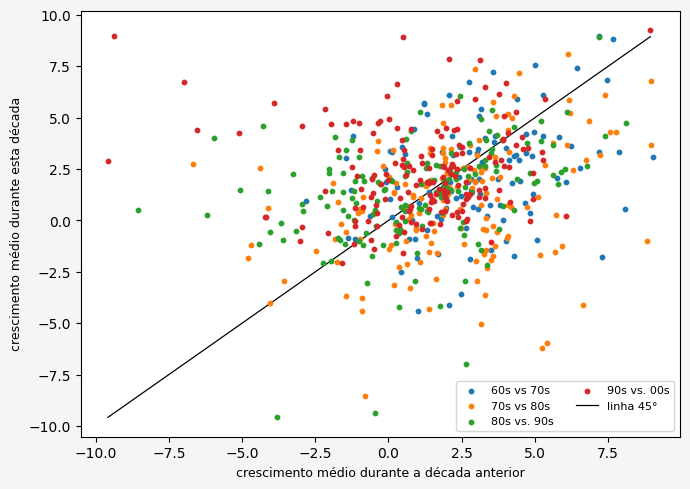

In [31]:
# todos os países: correlações do crescimento por década
# agregar para a média por país (já há uma linha por país)
fig7a = gr_wide.copy()
 
DECADE_PAIRS = [
    ("gr_1960", "gr_1970", "60s vs 70s"),
    ("gr_1970", "gr_1980", "70s vs 80s"),
    ("gr_1980", "gr_1990", "80s vs. 90s"),
    ("gr_1990", "gr_2000", "90s vs. 00s"),
]
COLORS_7 = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
 
fig, ax = plt.subplots(figsize=(7, 5))
 
for (prev, curr, lbl), col in zip(DECADE_PAIRS, COLORS_7):
    sub = fig7a[[prev, curr]].dropna()
    ax.scatter(sub[prev], sub[curr], s=10, color=col, label=lbl, zorder=3)
 
# Linha de 45 graus (referência)
all_vals = pd.concat([fig7a[c] for c in ["gr_1990"]], ignore_index=True).dropna()
ref_range = np.linspace(fig7a["gr_1990"].min(), fig7a["gr_1990"].max(), 100)
ax.plot(ref_range, ref_range, color="black", linewidth=0.9, label="linha 45°")
 
ax.set_xlabel("crescimento médio durante a década anterior", fontsize=9)
ax.set_ylabel("crescimento médio durante esta década",    fontsize=9)
ax.legend(fontsize=8, ncol=2)
ax.set_facecolor("white")
fig.patch.set_facecolor("#f5f5f5")
fig.tight_layout()

Correlação do crescimento do PIB per capita em décadas consecutivas (LICs)


--- Correlações (Apenas LICs) ---
  60s vs 70s: rho = 0.011
  70s vs 80s: rho = -0.118
  80s vs. 90s: rho = 0.025
  90s vs. 00s: rho = -0.212


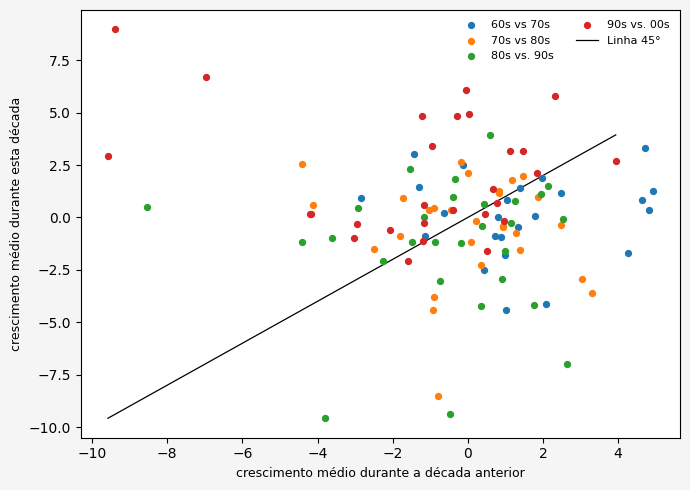

In [32]:
# apenas países de baixa renda + correlações no console
fig7b = gr_wide[gr_wide["ig3"] == "Low income"].copy()
 
print("\n--- Correlações (Apenas LICs) ---")
for prev, curr, lbl in DECADE_PAIRS:
    sub = fig7b[[prev, curr]].dropna()
    if len(sub) > 1:
        rho, _ = stats.pearsonr(sub[prev], sub[curr])
        print(f"  {lbl}: rho = {round(rho, 3)}")
 
fig, ax = plt.subplots(figsize=(7, 5))
 
for (prev, curr, lbl), col in zip(DECADE_PAIRS, COLORS_7):
    sub = fig7b[[prev, curr]].dropna()
    ax.scatter(sub[prev], sub[curr], s=18, color=col, label=lbl, zorder=3)
 
ref_range = np.linspace(fig7b["gr_1990"].dropna().min(),
                        fig7b["gr_1990"].dropna().max(), 100)
ax.plot(ref_range, ref_range, color="black", linewidth=0.9, label="Linha 45°")
 
ax.set_xlabel("crescimento médio durante a década anterior", fontsize=9)
ax.set_ylabel("crescimento médio durante esta década",    fontsize=9)
ax.legend(fontsize=8, ncol=2, frameon=False)
ax.set_facecolor("white")
fig.patch.set_facecolor("#f5f5f5")
fig.tight_layout()

### III. Considerações teóricas

- Hipótese de convergência: a distribuição de longo prazo da renda per capita entre países é independente das condições iniciais.
- Convergência: redução das disparidades ao longo do tempo (absoluta) ou dependente das condições iniciais (condicional).
- Convergência: em mercados de capitais perfeitos, ocorreria instantaneamente; na prática, fricções explicam a lenta (ou inexistente) equalização entre países.

### IV. Conceitos de Convergência

- Os testes de convergência mais elementares são os chamados testes de $\beta$-convergência.
- Outra possibilidade economicamente interessante é a convergência em clubes.
- Autores sugerem que testes de convergência devem investigar se a variância realmente diminui entre dois pontos no tempo, ou seja, se há $\sigma$-convergência.

### V. Evidência Empírica

- Modelos lineares
- Modelos não lineares
    - Modelos com parâmetros que variam suavemente
    - Modelos de distribuição
- Modelos de séries temporais
    - Abordagens de longa memória
    - Dinâmica de transição
    - Abordagens de agrupamento
 - Distribuição da renda entre indivíduos

### VI. Conclusão

- Como mostrado, a convergência é difícil de definir com precisão.
- Há um amplo consenso de que não há evidências que sustentem a convergência absoluta na renda per capita entre países.
- O crescimento e a convergência são processos irregulares e heterogêneos entre países.
- Na interpretação dos autores, as evidências mostram que o otimismo recente em favor de uma convergência rápida e sustentável é infundado.